In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)

Path to dataset files: /home/greg/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
# Explore the dataset structure
dataset_path = path
print(f"Dataset path: {dataset_path}")
print("\nFolder structure:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # Only show first 2 levels
        subindent = ' ' * 2 * (level + 1)
        for file in files[:2]:  # Show first 2 files
            print(f'{subindent}{file}')

Dataset path: /home/greg/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8

Folder structure:
8/
  test/
    soy beans/
    tomato/
    corn/
    pineapple/
    pomegranate/
    pear/
    turnip/
    ginger/
    chilli pepper/
    beetroot/
    raddish/
    garlic/
    watermelon/
    sweetcorn/
    banana/
    apple/
    spinach/
    potato/
    onion/
    lemon/
    capsicum/
    lettuce/
    grapes/
    mango/
    cucumber/
    cabbage/
    paprika/
    carrot/
    sweetpotato/
    orange/
    bell pepper/
    peas/
    eggplant/
    cauliflower/
    jalepeno/
    kiwi/
  validation/
    soy beans/
    tomato/
    corn/
    pineapple/
    pomegranate/
    pear/
    turnip/
    ginger/
    chilli pepper/
    beetroot/
    raddish/
    garlic/
    watermelon/
    sweetcorn/
    banana/
    apple/
    spinach/
    potato/
    onion/
    lemon/
    capsicum/
    lettuce/
    grapes/
    mango/
    cucumber/
    cabbage/
    paprika/
    carrot/
    sw

In [5]:
# Define data transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load datasets from folder structure
train_dataset = datasets.ImageFolder(os.path.join(dataset_path, 'train'), transform=train_transforms)
test_dataset = datasets.ImageFolder(os.path.join(dataset_path, 'test'), transform=val_transforms)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Display dataset information
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")

Number of training samples: 3115
Number of test samples: 359
Number of classes: 36
Classes: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [10]:
# Load pre-trained ResNet18 model with transfer learning
model = models.resnet18(pretrained=True)

# Freeze early layers (keep learned features)
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer
num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Unfreeze the last layer and fc layer for fine-tuning
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
print(f"Model loaded and moved to {device}")
print(f"Final layer updated to output {num_classes} classes")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam (lr=0.001)")

Model loaded and moved to cpu
Final layer updated to output 36 classes
Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


In [11]:
# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'loss': running_loss / total, 'acc': 100 * correct / total})
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

print("Training and validation functions defined!")

Training and validation functions defined!


In [12]:
# Train the model
num_epochs = 15
best_acc = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, _, _ = validate(model, test_loader, criterion, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_fruit_veg_model.pth')
        print("✓ Best model saved!")
    
    # Adjust learning rate
    scheduler.step(val_loss)

print("\nTraining complete!")


Epoch 1/15
--------------------------------------------------


Training:   0%|          | 0/98 [00:00<?, ?it/s]/home/greg/anaconda3/lib/python3.13/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  15%|█▌        | 15/98 [00:10<00:58,  1.43it/s, loss=0.114, acc=5.42]/home/greg/anaconda3/lib/python3.13/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training: 100%|██████████| 98/98 [01:05<00:00,  1.50it/s, loss=0.0816, acc=37]  


Train Loss: 2.5950 | Train Acc: 37.05%
Val Loss: 1.2260 | Val Acc: 71.31%
✓ Best model saved!

Epoch 2/15
--------------------------------------------------


Training:   6%|▌         | 6/98 [00:04<00:57,  1.59it/s, loss=0.0533, acc=60.9]/home/greg/anaconda3/lib/python3.13/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  12%|█▏        | 12/98 [00:08<00:49,  1.73it/s, loss=0.0516, acc=62.5]/home/greg/anaconda3/lib/python3.13/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training: 100%|██████████| 98/98 [01:08<00:00,  1.43it/s, loss=0.044, acc=68]   


Train Loss: 1.3991 | Train Acc: 68.03%
Val Loss: 0.7264 | Val Acc: 82.17%
✓ Best model saved!

Epoch 3/15
--------------------------------------------------


...

Train Loss: 0.5399 | Train Acc: 84.17%
Val Loss: 0.3149 | Val Acc: 89.42%

Epoch 14/15
--------------------------------------------------


Training:   7%|▋         | 7/98 [00:05<01:03,  1.43it/s, loss=0.0152, acc=85.7]/home/greg/anaconda3/lib/python3.13/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  12%|█▏        | 12/98 [00:09<01:00,  1.42it/s, loss=0.0158, acc=84.9]/home/greg/anaconda3/lib/python3.13/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training: 100%|██████████| 98/98 [01:04<00:00,  1.51it/s, loss=0.0166, acc=84]  


Train Loss: 0.5275 | Train Acc: 83.98%
Val Loss: 0.3308 | Val Acc: 88.02%

Epoch 15/15
--------------------------------------------------


Training:   0%|          | 0/98 [00:00<?, ?it/s]/home/greg/anaconda3/lib/python3.13/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  37%|███▋      | 36/98 [00:23<00:34,  1.82it/s, loss=0.0149, acc=85.2]/home/greg/anaconda3/lib/python3.13/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training: 100%|██████████| 98/98 [01:00<00:00,  1.62it/s, loss=0.0164, acc=84.7]


Train Loss: 0.5209 | Train Acc: 84.72%
Val Loss: 0.3185 | Val Acc: 89.97%

Training complete!


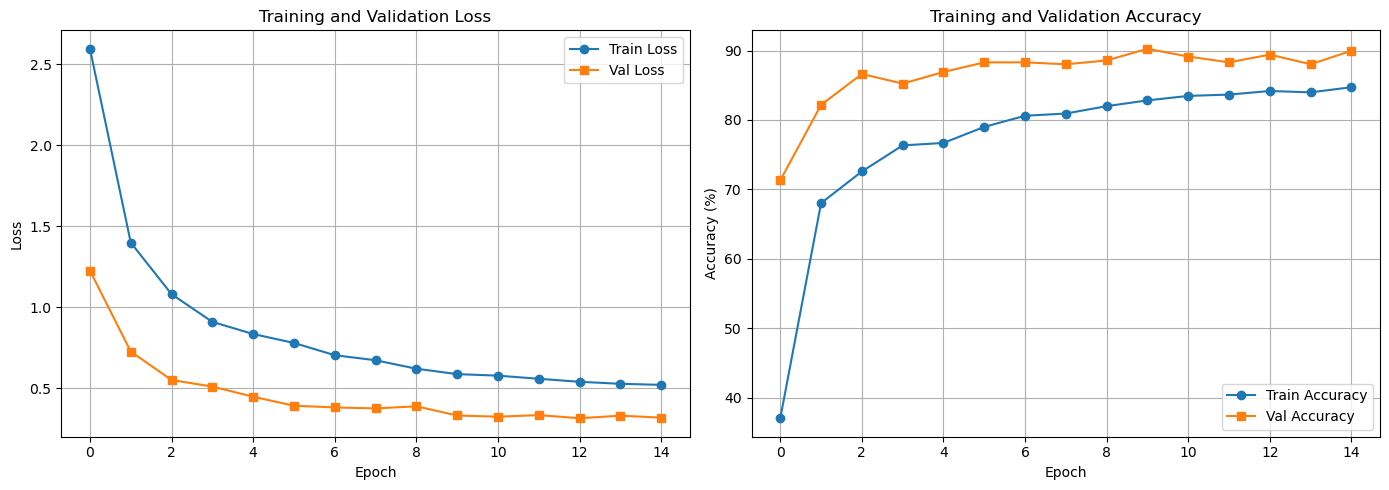

Best validation accuracy: 90.25%


In [13]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['val_acc'], label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {best_acc:.2f}%")

Final Model Evaluation

Classification Report:
               precision    recall  f1-score   support

        apple       0.86      0.60      0.71        10
       banana       0.78      0.78      0.78         9
     beetroot       1.00      1.00      1.00        10
  bell pepper       0.88      0.70      0.78        10
      cabbage       1.00      1.00      1.00        10
     capsicum       0.67      0.80      0.73        10
       carrot       1.00      1.00      1.00        10
  cauliflower       1.00      1.00      1.00        10
chilli pepper       0.59      1.00      0.74        10
         corn       0.59      1.00      0.74        10
     cucumber       1.00      1.00      1.00        10
     eggplant       1.00      1.00      1.00        10
       garlic       0.91      1.00      0.95        10
       ginger       1.00      1.00      1.00        10
       grapes       1.00      0.90      0.95        10
     jalepeno       0.82      0.90      0.86        10
         kiwi    

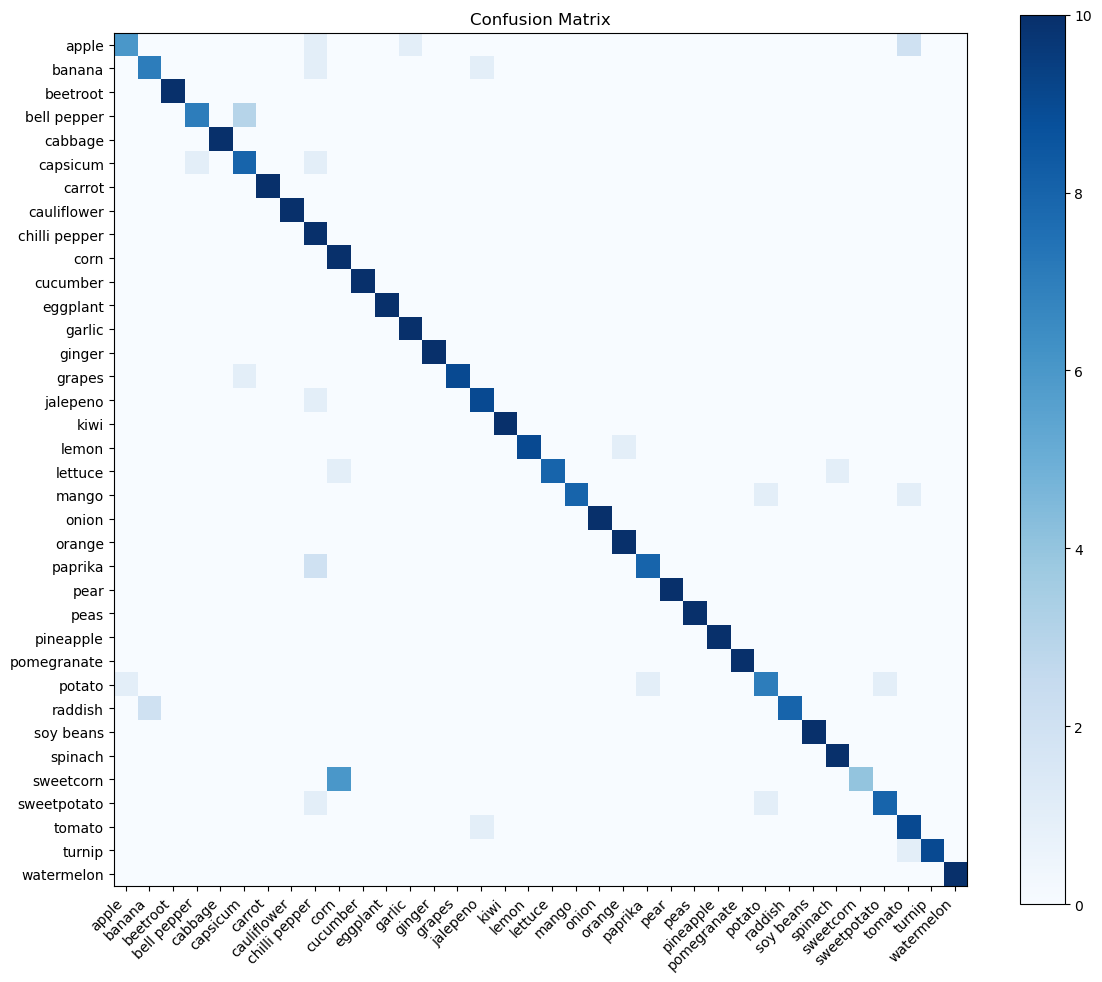

In [14]:
# Final evaluation on test set
print("Final Model Evaluation")
print("=" * 50)

# Load best model
model.load_state_dict(torch.load('best_fruit_veg_model.pth'))

# Get predictions
_, _, all_preds, all_labels = validate(model, test_loader, criterion, device)

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion matrix visualization
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(range(len(train_dataset.classes)), train_dataset.classes, rotation=45, ha='right')
plt.yticks(range(len(train_dataset.classes)), train_dataset.classes)
plt.tight_layout()
plt.show()

In [20]:
# Function to make predictions on new images
def predict_image(image_path, model, class_names, device):
    """Predict the fruit/vegetable in a single image"""
    model.eval()
    
    # Load and transform image
    image = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    ])(Image.open(image_path).convert('RGB'))
    
    image = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        top_pred = torch.argmax(probabilities, 1)
    
    predicted_class = class_names[top_pred.item()]
    confidence = probabilities[0][top_pred].item() * 100
    
    return predicted_class, confidence, probabilities[0].cpu().numpy()

# Example usage (uncomment if you have an image to test)
from PIL import Image
image_path = "/home/greg/Desktop/ML/Fruit_n_veg/papaya.jpeg"
pred_class, confidence, _ = predict_image(image_path, model, train_dataset.classes, device)
print(f"Prediction: {pred_class} (Confidence: {confidence:.2f}%)")

Prediction: orange (Confidence: 29.06%)
